# Logistic Regression Baseline — Click Prediction

My own baseline pass, built from the cleaning/transform plan in `EDA_REPORT.md`
rather than from scratch guesswork. Trained on `dataset/train.csv`, evaluated on
the time-held-out `dataset/test.csv`.

Differences from a naive baseline, per the EDA findings:

- **Drop `campaign_id`, `customer`** — functionally redundant with `adgroup_id`
  (each ad maps to exactly one campaign/customer; 217 of 248 campaigns contain a
  single ad group) — §6.
- **Decode the `0` sentinels** in `brand`, `cms_segid`, `pvalue_level`,
  `new_user_class_level` to an explicit `"unknown"` category instead of leaving
  them as a bare numeric `0` — §3.
- **`price`**: `log1p` then `StandardScaler` — it's right-skewed (skew 1.96) — §4.
- **`hour`**: cyclic `sin`/`cos` encoding instead of one-hot, so hour 23 sits next
  to hour 0 — §7.
- **Validation is temporal**, not random `KFold` — the test set is a strict future
  holdout, so a random split would leak future impressions of the same ad — §8.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Load + sanity guard

`EDA_REPORT.md` §0 flags that an earlier revision of `train.csv` had been
round-tripped through Excel, which silently truncated timestamps. Keep the
guard even though the current files are clean.


In [2]:
train = pd.read_csv("dataset/train.csv", parse_dates=["time_stamp"])
test = pd.read_csv("dataset/test.csv", parse_dates=["time_stamp"])

assert train["time_stamp"].dt.second.nunique() > 1, "train.csv lost seconds - regenerate"

print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train['click'].mean():.4%}  |  test CTR: {test['click'].mean():.4%}")


train: (240000, 21) test: (60000, 21)
train CTR: 20.1858%  |  test CTR: 19.2567%


## Cleaning (EDA_REPORT.md §1-3, §6)

- Drop `userid` (row id), `time_stamp`/`date` (superseded by `hour`/`weekday`;
  `date` also has an unseen level in test — §8), `campaign_id`/`customer`
  (redundant with `adgroup_id` — §6).
- Decode the `0` sentinel to `"unknown"` in the four columns where it means
  "missing", not a real level (§3). `occupation`'s `0` is a real level
  ("not a student") and is left alone.


In [3]:
DROP_COLS = ["userid", "time_stamp", "date", "campaign_id", "customer"]
SENTINEL_COLS = ["brand", "cms_segid", "pvalue_level", "new_user_class_level"]


def clean(df):
    df = df.drop(columns=DROP_COLS).copy()
    for col in SENTINEL_COLS:
        is_zero = df[col] == 0
        df[col] = df[col].astype("Int64").astype(str)
        df.loc[is_zero, col] = "unknown"
    return df


train_c = clean(train)
test_c = clean(test)
train_c[SENTINEL_COLS].head()


,brand,cms_segid,pvalue_level,new_user_class_level
0,454237,unknown,unknown,4
1,82527,44,2,2
2,unknown,unknown,unknown,2
3,224164,unknown,unknown,2
4,82527,unknown,unknown,4


## Feature engineering (EDA_REPORT.md §4, §7)

- `price`: `log1p` (fixes the right skew), scaled downstream by the pipeline.
- `hour`: cyclic `sin`/`cos` so hour 23 and hour 0 are adjacent instead of at
  opposite ends of a one-hot vector.

Everything else is one-hot with `handle_unknown="ignore"` — the catalog is fixed
to 300 products so there are no unseen `adgroup_id`/`cate_id`/`brand` levels in
test (§8), but `handle_unknown="ignore"` is kept as a cheap safety net.


In [4]:
def add_engineered(df):
    df = df.copy()
    df["price_log1p"] = np.log1p(df["price"])
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    return df


train_c = add_engineered(train_c)
test_c = add_engineered(test_c)

NUMERIC_FEATURES = ["price_log1p", "hour_sin", "hour_cos"]
ONEHOT_FEATURES = [
    "adgroup_id", "cate_id", "brand", "pid", "cms_segid", "cms_group_id",
    "final_gender_code", "age_level", "pvalue_level", "shopping_level",
    "occupation", "new_user_class_level", "weekday",
]
FEATURES = NUMERIC_FEATURES + ONEHOT_FEATURES
TARGET = "click"


## Temporal validation split (EDA_REPORT.md §8)

The provided test set is a strict future holdout (every test impression
post-dates every train impression), so model-selection validation has to mirror
that instead of a random `KFold`, or it reports an optimistic score. `train`
spans `2017-05-05`..`2017-05-12`; hold out the last two days (`05-11`, `05-12`,
~20% of rows) as a temporal validation slice, fit on the rest.


In [5]:
VAL_CUTOFF = "2017-05-11"
fit_mask = train["date"] < VAL_CUTOFF
val_mask = ~fit_mask

X_fit, y_fit = train_c.loc[fit_mask, FEATURES], train_c.loc[fit_mask, TARGET]
X_val, y_val = train_c.loc[val_mask, FEATURES], train_c.loc[val_mask, TARGET]

print(f"fit:   {X_fit.shape}  ({train.loc[fit_mask, 'date'].min()} .. {train.loc[fit_mask, 'date'].max()})")
print(f"val:   {X_val.shape}  ({train.loc[val_mask, 'date'].min()} .. {train.loc[val_mask, 'date'].max()})")


fit:   (192257, 16)  (2017-05-05 .. 2017-05-10)
val:   (47743, 16)  (2017-05-11 .. 2017-05-12)


In [6]:
def build_pipeline(clf):
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ONEHOT_FEATURES),
    ])
    return Pipeline([
        ("preprocess", preprocess),
        ("clf", clf),
    ])


val_model = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
val_model.fit(X_fit, y_fit)

val_score = val_model.predict_proba(X_val)[:, 1]
print(f"Temporal-val AUC:      {roc_auc_score(y_val, val_score):.4f}")
print(f"Temporal-val log loss: {log_loss(y_val, val_score):.4f}")


Temporal-val AUC:      0.5772
Temporal-val log loss: 0.4923


## Final fit and test evaluation

Validation above is only for checking the pipeline generalizes across time
before touching `test.csv`. Refit on the full `train` set for the number
reported against `test.csv`.


In [7]:
X_train, y_train = train_c[FEATURES], train_c[TARGET]
X_test, y_test = test_c[FEATURES], test_c[TARGET]

model = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_score)
ll = log_loss(y_test, y_score)
print(f"Test AUC:      {auc:.4f}  (0.5 = random)")
print(f"Test log loss: {ll:.4f}  (lower is better)")


Test AUC:      0.5765  (0.5 = random)
Test log loss: 0.4856  (lower is better)


## Ranking evaluation: Precision@K / Recall@K

CTR is imbalanced enough that AUC/log loss alone don't say much about "would
this model actually surface the right product". Treat every real click in the
test period as one query: score all 300 catalog products for that context,
rank them, and check where the actually-clicked product landed.

- **Recall@K** here is HitRate@K — each query has exactly one relevant product,
  so recall@K = the fraction of queries where it lands in the top K.
- **Precision@K** pools every query's K slots together: (correct slots) / (K ×
  n_queries).
- **Random baseline**: with 300 products, a random top-K list contains the true
  product with probability `K / 300`.


In [8]:
PRODUCT_FEATURES = ["adgroup_id", "cate_id", "brand", "price"]
USER_FEATURES = [
    "cms_segid", "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]
K_VALUES = [10, 50, 100]

catalog = (
    pd.concat([train_c[PRODUCT_FEATURES], test_c[PRODUCT_FEATURES]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)
catalog = add_engineered(catalog.assign(hour=0))  # placeholder hour, overwritten per-query below
n_catalog = len(catalog)
print(f"Product catalog: {n_catalog} unique products")


Product catalog: 300 unique products


In [9]:
queries = test_c[test_c["click"] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)
print(f"Evaluating {n_queries} clicks")

# Cross join every click's user context with every catalog product, then re-derive
# the engineered price/hour features (catalog's placeholder hour gets overwritten
# by the query's real hour here).
cross = queries[["query_id", "adgroup_id"] + USER_FEATURES].rename(
    columns={"adgroup_id": "true_adgroup_id", "hour": "query_hour"}
).merge(catalog.drop(columns=["hour", "hour_sin", "hour_cos"]), how="cross")
cross["hour"] = cross["query_hour"]
cross["hour_sin"] = np.sin(2 * np.pi * cross["hour"] / 24)
cross["hour_cos"] = np.cos(2 * np.pi * cross["hour"] / 24)

cross["score"] = model.predict_proba(cross[FEATURES])[:, 1]
cross["rank"] = cross.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1


Evaluating 11554 clicks


In [10]:
true_product_rank = (
    cross.loc[cross["adgroup_id"] == cross["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)

rows = []
for k in K_VALUES:
    hit = true_product_rank < k
    recall_at_k = hit.mean()
    precision_at_k = hit.sum() / (n_queries * k)
    random_precision = 1 / n_catalog
    random_recall = k / n_catalog
    rows.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Random Precision@K": random_precision,
        "Random Recall@K": random_recall,
        "Precision lift": precision_at_k / random_precision,
    })

results = pd.DataFrame(rows).set_index("K")
results


,Precision@K,Recall@K,Random Precision@K,Random Recall@K,Precision lift
K,,,,,
10,0.009659,0.096590,0.003333,0.033333,2.897698
50,0.006947,0.347326,0.003333,0.166667,2.083954
100,0.005386,0.538601,0.003333,0.333333,1.615804


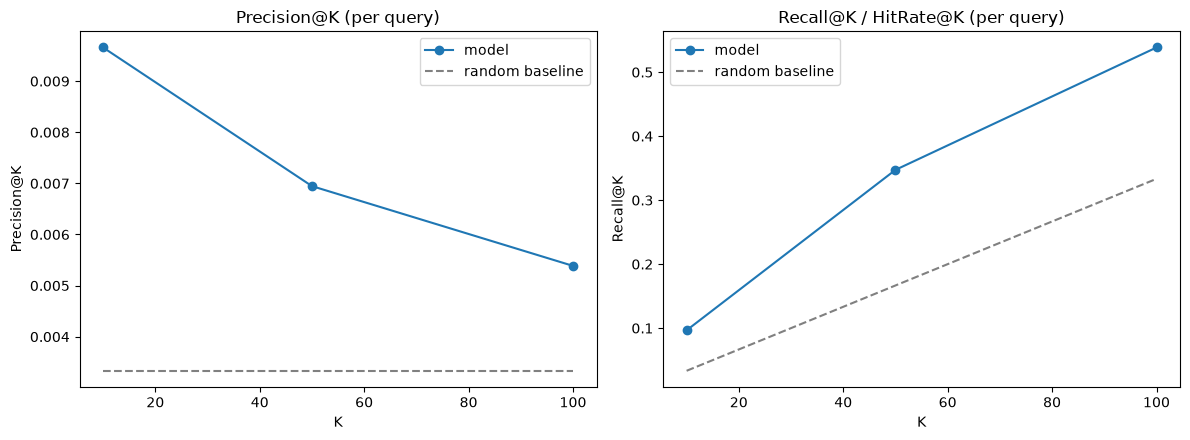

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(results.index, results["Precision@K"], marker="o", label="model")
axes[0].plot(results.index, results["Random Precision@K"], color="gray", linestyle="--", label="random baseline")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (per query)")
axes[0].legend()

axes[1].plot(results.index, results["Recall@K"], marker="o", label="model")
axes[1].plot(results.index, results["Random Recall@K"], color="gray", linestyle="--", label="random baseline")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K / HitRate@K (per query)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Feature signal check

`EDA_REPORT.md` §5 found `adgroup_id` carries an order of magnitude more signal
than any single user attribute, and predicted almost no lift from main-effect
user features alone. Sanity-check that against the fitted coefficients: the
largest-magnitude weights should concentrate on `adgroup_id`/`cate_id` levels,
not user demographics.


In [12]:
onehot = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = list(onehot.get_feature_names_out(ONEHOT_FEATURES))
coefs = pd.Series(
    model.named_steps["clf"].coef_[0][len(NUMERIC_FEATURES):],
    index=feature_names,
)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)


adgroup_id_512438   -1.053248
adgroup_id_749687    0.852629
adgroup_id_507145   -0.797732
adgroup_id_739213    0.686375
adgroup_id_837036   -0.672910
adgroup_id_774050    0.602533
adgroup_id_825544    0.597665
adgroup_id_710164    0.565411
adgroup_id_725105    0.551540
adgroup_id_632432    0.531326
adgroup_id_724274    0.528657
adgroup_id_632232   -0.470396
adgroup_id_676171   -0.446956
adgroup_id_606601    0.445935
adgroup_id_659289   -0.433907
dtype: float64

## Model comparison — is logistic regression actually the best fit here?

`EDA_REPORT.md` §5 predicted that a linear, main-effects-only model would miss
most of the signal, since `adgroup_id` dominates and user features mostly
matter through interactions with it — which tree-based models capture
automatically by splitting on combinations of features, no manual crossing
needed. Compare three classifiers on the *same* cleaned/engineered features and
the *same* one-hot preprocessing, so the comparison isolates the model choice:

- **Logistic Regression** — the baseline above, linear, main effects only.
- **Random Forest** — bagged decision trees, captures interactions and
  non-linearities, less prone to overfitting on noisy features than a single
  tree.
- **Histogram Gradient Boosting** (`HistGradientBoostingClassifier`) —
  sklearn's fast GBM implementation; usually the strongest of the three on
  tabular data like this.


In [13]:
cross_static = cross.drop(columns=["score", "rank"])


def evaluate_model(name, predict_fn, k_values=K_VALUES):
    # predict_fn(df) -> P(click=1) array; lets sklearn-Pipeline models and the
    # native-categorical HGB model (see below) share one evaluation path.
    y_score = predict_fn(test_c)
    row = {
        "model": name,
        "AUC": roc_auc_score(y_test, y_score),
        "LogLoss": log_loss(y_test, y_score),
    }

    scored = cross_static.copy()
    scored["score"] = predict_fn(scored)
    scored["rank"] = (
        scored.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1
    )
    true_rank = (
        scored.loc[scored["adgroup_id"] == scored["true_adgroup_id"], ["query_id", "rank"]]
        .set_index("query_id")["rank"]
    )
    for k in k_values:
        hit = true_rank < k
        row[f"Recall@{k}"] = hit.mean()
        row[f"Precision@{k}"] = hit.sum() / (n_queries * k)
    return row


In [14]:
rf = build_pipeline(
    RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_SEED,
    )
)
rf.fit(X_train, y_train)
print("random forest fit done")


random forest fit done


HistGradientBoosting gets its own path: one-hot would blow the cross-join
evaluation frame up to ~3.5M rows x 602 dense columns (~17GB) and OOM. GBMs
don't need one-hot anyway — pass the categorical columns as pandas `category`
dtype and let `categorical_features="from_dtype"` split on raw category ids
directly, which is both the idiomatic sklearn API and far cheaper.

One exception: sklearn caps native categorical cardinality at `max_bins`
(255), and `adgroup_id` has 300 levels. Ordinal-encode just that one column
and let it ride as a plain numeric feature — a GBM can still isolate
individual ad groups via repeated splits, it's just not as clean as a true
categorical split.


In [15]:
ADGROUP_CATEGORIES = sorted(pd.concat([train_c["adgroup_id"], test_c["adgroup_id"]]).unique())
HGB_CATEGORICAL = [c for c in ONEHOT_FEATURES if c != "adgroup_id"]


def as_hgb_frame(df):
    d = df[FEATURES].copy()
    d["adgroup_id"] = pd.Categorical(d["adgroup_id"], categories=ADGROUP_CATEGORIES).codes.astype("float64")
    for col in HGB_CATEGORICAL:
        d[col] = d[col].astype("category")
    return d


hgb = HistGradientBoostingClassifier(
    max_iter=200, categorical_features="from_dtype", random_state=RANDOM_SEED,
)
hgb.fit(as_hgb_frame(train_c), y_train)
print("hist gradient boosting fit done")


hist gradient boosting fit done


### LightGBM / XGBoost / CatBoost — no cardinality cap on categoricals

Unlike `HistGradientBoostingClassifier`, these three have first-class support
for high-cardinality categorical columns, so `adgroup_id` (300 levels) doesn't
need the ordinal-encoding workaround above — it can be a real categorical
split in all three.

- **LightGBM / XGBoost**: pass columns as pandas `category` dtype. The
  category *set* has to stay identical across train/test/cross-join calls (a
  category dtype built independently per call can silently reassign codes),
  so build one shared `categories=` mapping per column up front instead of
  calling `.astype("category")` fresh each time.
- **CatBoost**: takes raw columns (str/int) directly plus a `cat_features`
  list — its ordered target-statistic encoding does not need pre-built
  category dtypes at all.


In [16]:
CATEGORY_LEVELS = {
    col: sorted(pd.concat([train_c[col], test_c[col]]).unique())
    for col in ONEHOT_FEATURES
}


def as_native_cat_frame(df):
    d = df[FEATURES].copy()
    for col in ONEHOT_FEATURES:
        d[col] = pd.Categorical(d[col], categories=CATEGORY_LEVELS[col])
    return d


lgbm = LGBMClassifier(n_estimators=200, random_state=RANDOM_SEED, verbose=-1)
lgbm.fit(as_native_cat_frame(train_c), y_train, categorical_feature=ONEHOT_FEATURES)
print("lightgbm fit done")

xgb = XGBClassifier(
    n_estimators=200, tree_method="hist", enable_categorical=True,
    random_state=RANDOM_SEED,
)
xgb.fit(as_native_cat_frame(train_c), y_train)
print("xgboost fit done")

catboost = CatBoostClassifier(
    iterations=200, random_state=RANDOM_SEED, verbose=False,
)
catboost.fit(train_c[FEATURES], y_train, cat_features=ONEHOT_FEATURES)
print("catboost fit done")


lightgbm fit done


xgboost fit done


catboost fit done


In [17]:
comparison = pd.DataFrame([
    evaluate_model("Logistic Regression", lambda df: model.predict_proba(df[FEATURES])[:, 1]),
    evaluate_model("Random Forest", lambda df: rf.predict_proba(df[FEATURES])[:, 1]),
    evaluate_model("HistGradientBoosting", lambda df: hgb.predict_proba(as_hgb_frame(df))[:, 1]),
    evaluate_model("LightGBM", lambda df: lgbm.predict_proba(as_native_cat_frame(df))[:, 1]),
    evaluate_model("XGBoost", lambda df: xgb.predict_proba(as_native_cat_frame(df))[:, 1]),
    evaluate_model("CatBoost", lambda df: catboost.predict_proba(df[FEATURES])[:, 1]),
]).set_index("model")
comparison


,AUC,LogLoss,Recall@10,Precision@10,Recall@50,Precision@50,Recall@100,Precision@100
model,,,,,,,,
Logistic Regression,0.576508,0.485599,0.096590,0.009659,0.347326,0.006947,0.538601,0.005386
Random Forest,0.569176,0.486799,0.111563,0.011156,0.351393,0.007028,0.495067,0.004951
HistGradientBoosting,0.570107,0.485996,0.099013,0.009901,0.340921,0.006818,0.517137,0.005171
LightGBM,0.563904,0.491061,0.082482,0.008248,0.303445,0.006069,0.508222,0.005082
XGBoost,0.542565,0.522647,0.056258,0.005626,0.259823,0.005196,0.470400,0.004704
CatBoost,0.564303,0.487768,0.090099,0.009010,0.347672,0.006953,0.531764,0.005318
